In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
STRIPES_PATH = (
    "/project2/fudenber_735/smaruj/sequence_design/"
    "ledidi_semifreddo_akita/analysis/natural_features/"
    "flames/mouse_selected_stripes_strength.tsv"
)
SCORE_COL  = "flame_strength_q3"   # chosen strength metric (75th percentile)
FILTER_COL = "flame_strength_mean" # filter: keep only stripes with mean > 0

df = pd.read_csv(STRIPES_PATH, sep="\t")

# Retain stripes with positive mean predicted signal.
selected_df = df[df[FILTER_COL] > 0].copy()
print(f"Stripes after filtering: {len(selected_df):,} / {len(df):,}")

Stripes after filtering: 1,485 / 2,215


## Distribution of flame strength (Q3 signal)

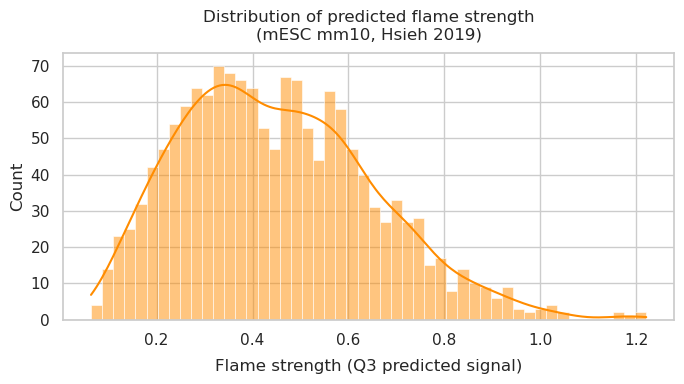

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.histplot(
    selected_df[SCORE_COL],
    bins=50,
    kde=True,
    color="darkorange",
    edgecolor="white",
    linewidth=0.4,
    ax=ax,
)

ax.set_xlabel("Flame strength (Q3 predicted signal)", labelpad=8)
ax.set_ylabel("Count")
ax.set_title("Distribution of predicted flame strength\n(mESC mm10, Hsieh 2019)", pad=10)

fig.tight_layout()
plt.show()

## Flame strength vs. Stripiness

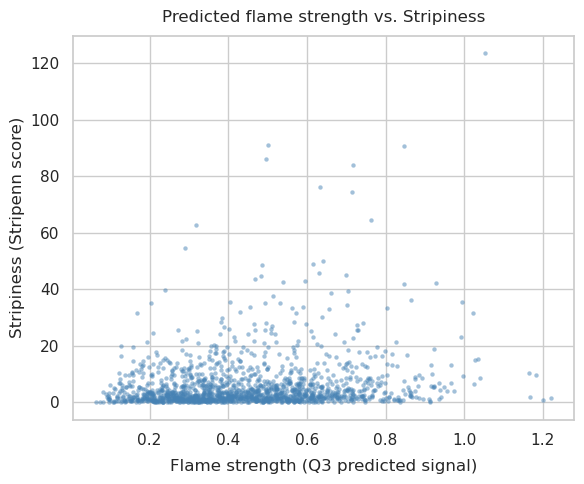

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    selected_df[SCORE_COL],
    selected_df["Stripiness"],
    s=10,
    alpha=0.5,
    color="steelblue",
    linewidths=0,
)

ax.set_xlabel("Flame strength (Q3 predicted signal)", labelpad=8)
ax.set_ylabel("Stripiness (Stripenn score)")
ax.set_title("Predicted flame strength vs. Stripiness", pad=10)

fig.tight_layout()
plt.show()

In [5]:
selected_df.to_csv("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/natural_features/flames/mouse_stripes_strength.tsv", sep="\t", index=False)